In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/ColabNotebooks/

/content/drive/MyDrive/ColabNotebooks


In [42]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and EDA

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
data = pd.read_csv('gk_jamaica_sales.csv')

In [6]:
data.head()

,store_id,date,month,day_of_week,parish,store_type,sku_category,store_open,near_transport_hub,competitor_nearby,normal_price_jmd,avg_unit_price_jmd,promo_active,promo_type,is_christmas_season,is_easter_week,is_carnival_season,is_back_to_school,school_holiday,jamaica_public_holiday,holiday_name,is_hurricane_season,weekly_rainfall_mm,customer_footfall,sales_volume_units,sales_jmd,sales_class
0,1001,07/03/2023,3,2,St. Catherine,Corner Shop,Baked Goods,1,0,0,199.08,99.54,1,BOGO,0,0,0,0,0,0,NaN,0,17.7,149,22,2189.88,Medium
1,1002,24/07/2024,7,3,St. Elizabeth,Wholesale/Chinese Shop,Tinned Meats,1,0,0,441.85,441.85,0,NaN,0,0,0,0,1,0,NaN,1,47.6,192,86,37999.10,Medium
2,1003,15/04/2024,4,1,Westmoreland,Supermarket,Juices,1,0,0,226.44,215.12,1,In-Store Demo,0,0,1,0,0,0,NaN,0,10.3,392,96,20651.52,High
3,1004,23/04/2023,4,7,Kingston,Wholesale/Chinese Shop,Tinned Meats,0,0,0,470.22,470.22,0,NaN,0,0,0,0,0,0,NaN,0,26.1,0,0,0.00,Low
4,1005,14/07/2024,7,7,Westmoreland,Wholesale/Chinese Shop,Tinned Meats,0,1,1,447.62,447.62,0,NaN,0,0,0,0,1,0,NaN,1,66.6,0,0,0.00,Low


In [8]:
data = data.drop(['promo_type', 'holiday_name', 'sales_class'], axis = 1)

In [10]:
data.isnull().sum()

,0
store_id,0
date,0
month,0
day_of_week,0
parish,0
store_type,0
sku_category,0
store_open,0
near_transport_hub,0
competitor_nearby,0


In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.shape

(100000, 24)

In [14]:
data.describe()

,store_id,month,day_of_week,store_open,near_transport_hub,competitor_nearby,normal_price_jmd,avg_unit_price_jmd,promo_active,is_christmas_season,is_easter_week,is_carnival_season,is_back_to_school,school_holiday,jamaica_public_holiday,is_hurricane_season,weekly_rainfall_mm,customer_footfall,sales_volume_units,sales_jmd
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,6.510360,4.006870,0.947570,0.536400,0.350180,354.700207,337.207888,0.238380,0.081920,0.035640,0.109130,0.077150,0.255120,0.027580,0.502330,37.808414,196.039810,50.309890,16279.468910
std,28867.657797,3.446678,2.003543,0.222894,0.498676,0.477029,159.821810,160.475561,0.426095,0.274244,0.185392,0.311804,0.266831,0.435931,0.163767,0.499997,33.738706,196.413507,53.819002,19627.564935
min,1001.000000,1.000000,1.000000,0.000000,0.000000,0.000000,170.200000,85.110000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26000.750000,4.000000,2.000000,1.000000,0.000000,0.000000,209.510000,202.650000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.500000,72.000000,15.000000,4076.980000
50%,51000.500000,7.000000,4.000000,1.000000,1.000000,0.000000,336.650000,319.790000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,28.200000,142.000000,33.000000,9212.295000
75%,76000.250000,10.000000,6.000000,1.000000,1.000000,1.000000,475.142500,465.150000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,55.900000,257.000000,68.000000,20410.350000
max,101000.000000,12.000000,7.000000,1.000000,1.000000,1.000000,734.400000,734.400000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,231.700000,3472.000000,846.000000,228333.600000


## Feature Engineering

In [23]:
# How much of a discount is being applied
data['discount_pct'] = (
    (data['normal_price_jmd'] - data['avg_unit_price_jmd']) / data['normal_price_jmd']
).clip(lower=0)  # avoid negatives from rounding

# Is the item being sold below normal price
data['is_discounted'] = (data['discount_pct'] > 0).astype(int)

In [26]:
# Parse date
data['date'] = pd.to_datetime(data['date'], dayfirst=True)

data['year']      = data['date'].dt.year
data['quarter']   = data['date'].dt.quarter
data['week_of_year'] = data['date'].dt.isocalendar().week.astype(int)
data['is_weekend'] = (data['day_of_week'] >= 6).astype(int)
data['is_month_start'] = data['date'].dt.is_month_start.astype(int)
data['is_month_end']   = data['date'].dt.is_month_end.astype(int)

In [29]:
#Combining all events into one feature
event_cols = [
    'is_christmas_season', 'is_easter_week', 'is_carnival_season',
    'is_back_to_school', 'school_holiday', 'jamaica_public_holiday'
]

data['event_pressure'] = data[event_cols].sum(axis=1)

In [30]:
# Keep a record of closed days
data['store_was_closed'] = (data['store_open'] == 0).astype(int)

# only on open-store records
data_model = data[data['store_open'] == 1].copy()

##Log Transform target

In [32]:
import numpy as np
data_model['sales_jmd_log'] = np.log1p(data_model['sales_jmd'])

data_model['footfall_log'] = np.log1p(data_model['customer_footfall'])

##Encoding and Scaling


In [33]:
data_model.head()

,store_id,date,month,day_of_week,parish,store_type,sku_category,store_open,near_transport_hub,competitor_nearby,normal_price_jmd,avg_unit_price_jmd,promo_active,is_christmas_season,is_easter_week,is_carnival_season,is_back_to_school,school_holiday,jamaica_public_holiday,is_hurricane_season,weekly_rainfall_mm,customer_footfall,sales_volume_units,sales_jmd,discount_pct,is_discounted,year,quarter,week_of_year,is_weekend,is_month_start,is_month_end,event_pressure,store_was_closed,sales_jmd_log,footfall_log
0,1001,2023-03-07,3,2,St. Catherine,Corner Shop,Baked Goods,1,0,0,199.08,99.54,1,0,0,0,0,0,0,0,17.7,149,22,2189.88,0.500000,1,2023,1,10,0,0,0,0,0,7.692059,5.010635
1,1002,2024-07-24,7,3,St. Elizabeth,Wholesale/Chinese Shop,Tinned Meats,1,0,0,441.85,441.85,0,0,0,0,0,1,0,1,47.6,192,86,37999.10,0.000000,0,2024,3,30,0,0,0,1,0,10.545344,5.262690
2,1003,2024-04-15,4,1,Westmoreland,Supermarket,Juices,1,0,0,226.44,215.12,1,0,0,1,0,0,0,0,10.3,392,96,20651.52,0.049991,1,2024,2,16,0,0,0,1,0,9.935593,5.973810
5,1006,2024-08-30,8,5,St. James,Corner Shop,Ketchup/Sauces,1,1,1,348.79,348.79,0,0,0,0,0,1,0,1,20.4,136,21,7324.59,0.000000,0,2024,3,35,0,0,0,1,0,8.899129,4.919981
6,1007,2024-02-24,2,6,St. Ann,Corner Shop,Juices,1,0,1,217.77,108.89,1,0,0,0,0,0,0,0,0.0,168,30,3266.70,0.499977,1,2024,1,8,1,0,0,0,0,8.091842,5.129899


In [34]:
data['parish'].unique()

array(['St. Catherine', 'St. Elizabeth', 'Westmoreland', 'Kingston',
       'St. James', 'St. Ann', 'St. Andrew', 'Manchester', 'St. Mary',
       'Clarendon', 'Portland', 'Hanover', 'Trelawny', 'St. Thomas'],
      dtype=object)

In [35]:
data['sku_category'].unique()

array(['Baked Goods', 'Tinned Meats', 'Juices', 'Ketchup/Sauces',
       'Cooking Oil'], dtype=object)

In [36]:
data['store_type'].unique()

array(['Corner Shop', 'Wholesale/Chinese Shop', 'Supermarket',
       'Gas Station Convenience'], dtype=object)

In [37]:
categorical_cols = ['parish', 'sku_category', 'store_type']
data_model = pd.get_dummies(data_model, columns=categorical_cols, drop_first=True)
display(data_model.head())

,store_id,date,month,day_of_week,store_open,near_transport_hub,competitor_nearby,normal_price_jmd,avg_unit_price_jmd,promo_active,is_christmas_season,is_easter_week,is_carnival_season,is_back_to_school,school_holiday,jamaica_public_holiday,is_hurricane_season,weekly_rainfall_mm,customer_footfall,sales_volume_units,sales_jmd,discount_pct,is_discounted,year,quarter,week_of_year,is_weekend,is_month_start,is_month_end,event_pressure,store_was_closed,sales_jmd_log,footfall_log,parish_Hanover,parish_Kingston,parish_Manchester,parish_Portland,parish_St. Andrew,parish_St. Ann,parish_St. Catherine,parish_St. Elizabeth,parish_St. James,parish_St. Mary,parish_St. Thomas,parish_Trelawny,parish_Westmoreland,sku_category_Cooking Oil,sku_category_Juices,sku_category_Ketchup/Sauces,sku_category_Tinned Meats,store_type_Gas Station Convenience,store_type_Supermarket,store_type_Wholesale/Chinese Shop
0,1001,2023-03-07,3,2,1,0,0,199.08,99.54,1,0,0,0,0,0,0,0,17.7,149,22,2189.88,0.500000,1,2023,1,10,0,0,0,0,0,7.692059,5.010635,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1002,2024-07-24,7,3,1,0,0,441.85,441.85,0,0,0,0,0,1,0,1,47.6,192,86,37999.10,0.000000,0,2024,3,30,0,0,0,1,0,10.545344,5.262690,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True
2,1003,2024-04-15,4,1,1,0,0,226.44,215.12,1,0,0,1,0,0,0,0,10.3,392,96,20651.52,0.049991,1,2024,2,16,0,0,0,1,0,9.935593,5.973810,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False
5,1006,2024-08-30,8,5,1,1,1,348.79,348.79,0,0,0,0,0,1,0,1,20.4,136,21,7324.59,0.000000,0,2024,3,35,0,0,0,1,0,8.899129,4.919981,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
6,1007,2024-02-24,2,6,1,0,1,217.77,108.89,1,0,0,0,0,0,0,0,0.0,168,30,3266.70,0.499977,1,2024,1,8,1,0,0,0,0,8.091842,5.129899,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False


In [38]:
# Columns to drop before modelling
drop_cols = [
    'store_id',
    'date',
    'store_open',
    'sales_volume_units',
    'sales_jmd',
]

feature_cols = [c for c in data_model.columns if c not in drop_cols + ['sales_jmd_log']]
target_col   = 'sales_jmd_log'

X = data_model[feature_cols]
y = data_model[target_col]

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")
print(X.dtypes)

Features: 47, Samples: 94757
month                                   int64
day_of_week                             int64
near_transport_hub                      int64
competitor_nearby                       int64
normal_price_jmd                      float64
avg_unit_price_jmd                    float64
promo_active                            int64
is_christmas_season                     int64
is_easter_week                          int64
is_carnival_season                      int64
is_back_to_school                       int64
school_holiday                          int64
jamaica_public_holiday                  int64
is_hurricane_season                     int64
weekly_rainfall_mm                    float64
customer_footfall                       int64
discount_pct                          float64
is_discounted                           int64
year                                    int32
quarter                                 int32
week_of_year                            int64
is_we

In [39]:
split_date = '2024-01-01'

X_train = X[data_model['date'] < split_date]
X_test  = X[data_model['date'] >= split_date]
y_train = y[data_model['date'] < split_date]
y_test  = y[data_model['date'] >= split_date]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

Train: 47374 rows | Test: 47383 rows


In [41]:
numeric_features = [
    'normal_price_jmd', 'avg_unit_price_jmd', 'discount_pct',
    'weekly_rainfall_mm', 'footfall_log', 'week_of_year', 'event_pressure'
]

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features]  = scaler.transform(X_test[numeric_features])

/tmp/ipykernel_11061/3872543911.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
/tmp/ipykernel_11061/3872543911.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[numeric_features]  = scaler.transform(X_test[numeric_features])


##Modeling and Evaluation

In [43]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("── Linear Regression ──")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_lr):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.4f}")

── Linear Regression ──
RMSE: 0.3038
MAE:  0.1664
R²:   0.9510


In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("── Random Forest ──")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_rf):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")

── Random Forest ──
RMSE: 0.1110
MAE:  0.0878
R²:   0.9935


In [53]:
# Convert log predictions back to JMD
y_pred_jmd = np.expm1(y_pred_rf)   # swap for whichever model wins
y_test_jmd = np.expm1(y_test)

print("── RF (JMD) ──")
print(f"RMSE: J${root_mean_squared_error(y_test_jmd, y_pred_jmd):,.0f}")
print(f"MAE:  J${mean_absolute_error(y_test_jmd, y_pred_jmd):,.0f}")

── RF (JMD) ──
RMSE: J$2,785
MAE:  J$1,462


##Hypertuning

In [55]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [6, 8, 10, 15, None],
    'min_samples_leaf':  [2, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=50,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV R²:", round(rf_search.best_score_, 4))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 15}
Best CV R²: 0.9953


In [56]:
best_rf = rf_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

print("── Tuned Random Forest ──")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_tuned):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_tuned):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_tuned):.4f}")

# Compare to untuned
print("\n── Baseline Random Forest ──")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_rf):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")

── Tuned Random Forest ──
RMSE: 0.0907
MAE:  0.0751
R²:   0.9956

── Baseline Random Forest ──
RMSE: 0.1110
MAE:  0.0878
R²:   0.9935


##Feature Importance

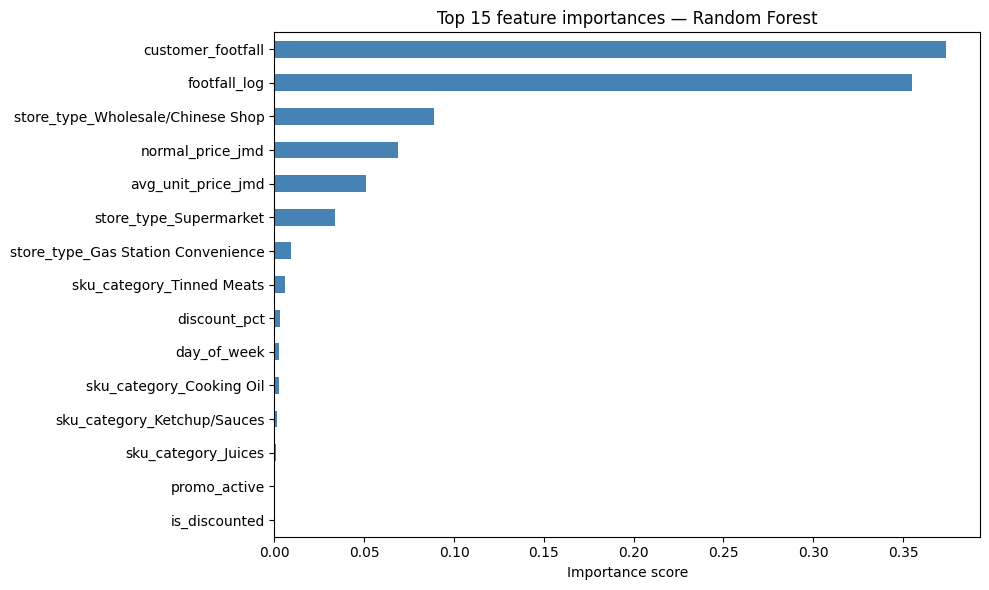

In [57]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 feature importances — Random Forest')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

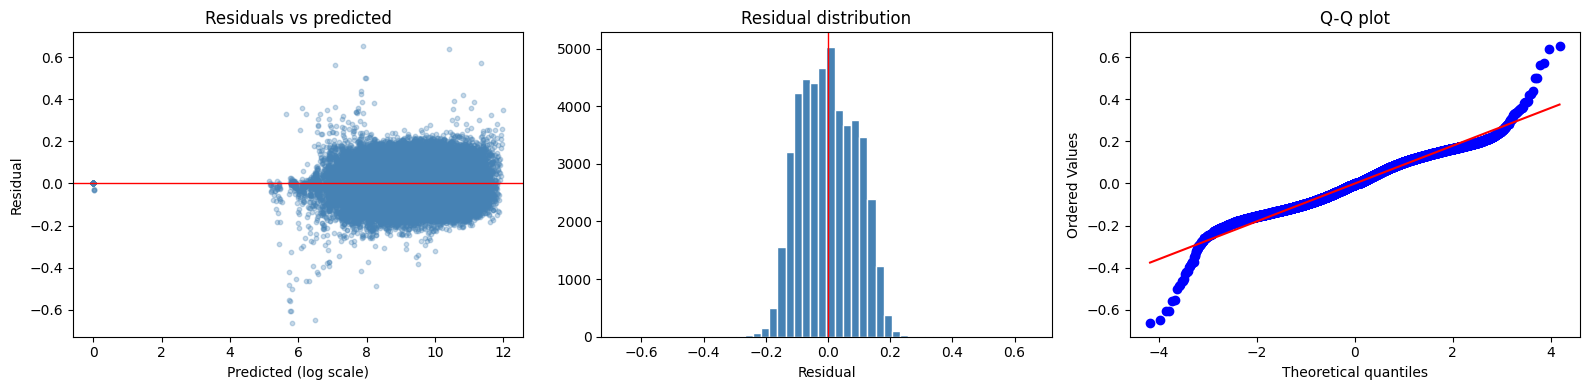

Mean residual:   -0.0003  (ideally ~0)
Std of residuals:0.0907


In [58]:
residuals = y_test - y_pred_tuned

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs predicted
axes[0].scatter(y_pred_tuned, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_title('Residuals vs predicted')
axes[0].set_xlabel('Predicted (log scale)')
axes[0].set_ylabel('Residual')

# Residual distribution
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1)
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual')

# Q-Q plot (checks if residuals are normally distributed)
from scipy import stats
stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q plot')

plt.tight_layout()
plt.show()

print(f"Mean residual:   {residuals.mean():.4f}  (ideally ~0)")
print(f"Std of residuals:{residuals.std():.4f}")

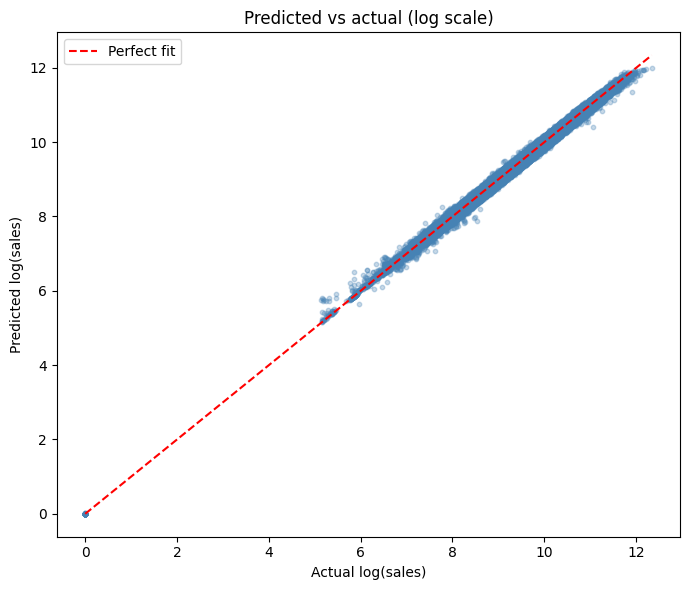

In [59]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.3, s=10, color='steelblue')

# Perfect prediction line
min_val = min(y_test.min(), y_pred_tuned.min())
max_val = max(y_test.max(), y_pred_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')

plt.title('Predicted vs actual (log scale)')
plt.xlabel('Actual log(sales)')
plt.ylabel('Predicted log(sales)')
plt.legend()
plt.tight_layout()
plt.show()

##Model Summary

In [62]:
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

# Log scale metrics
log_rmse = root_mean_squared_error(y_test, y_pred_tuned)
log_mae  = mean_absolute_error(y_test, y_pred_tuned)
log_r2   = r2_score(y_test, y_pred_tuned)

# JMD scale metrics
y_test_jmd  = np.expm1(y_test)
y_pred_jmd  = np.expm1(y_pred_tuned)
jmd_rmse    = root_mean_squared_error(y_test_jmd, y_pred_jmd)
jmd_mae     = mean_absolute_error(y_test_jmd, y_pred_jmd)
jmd_r2      = r2_score(y_test_jmd, y_pred_jmd)

summary = pd.DataFrame({
    'Metric':    ['RMSE', 'MAE', 'R²'],
    'Log scale': [round(log_rmse, 4), round(log_mae, 4), round(log_r2, 4)],
    'JMD scale': [f'J${jmd_rmse:,.0f}', f'J${jmd_mae:,.0f}', round(jmd_r2, 4)]
})

# Fix: Use data_model filtered by test index instead of the undefined 'daily'
test_dates = data_model.loc[y_test.index, 'date']

print("══════════════════════════════════")
print("   Tuned Random Forest — Summary  ")
print("══════════════════════════════════")
print(summary.to_string(index=False))
print(f"\nTest period: {test_dates.min().date()} → {test_dates.max().date()}")
print(f"Test samples: {len(y_test):,}")

══════════════════════════════════
   Tuned Random Forest — Summary  
══════════════════════════════════
Metric  Log scale JMD scale
  RMSE     0.0907   J$2,442
   MAE     0.0751   J$1,306
    R²     0.9956    0.9849

Test period: 2024-01-01 → 2024-12-30
Test samples: 47,383


## Model Packaging and Export
We will save the `best_rf` model and the `scaler` so they can be reused in other notebooks or applications.

In [63]:
import joblib

# Save the model
joblib.dump(best_rf, 'gk_sales_rf_model.joblib')

# Save the scaler (critical for new data)
joblib.dump(scaler, 'gk_sales_scaler.joblib')

print("Model and Scaler successfully saved!")

Model and Scaler successfully saved!


In [64]:
from google.colab import files

# Trigger browser download for both files
files.download('gk_sales_rf_model.joblib')
files.download('gk_sales_scaler.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### How to Reuse the Model and Scaler
To use these files in a new notebook or script, follow these steps:
1. Load the files using `joblib`.
2. Preprocess your new data (Encoding/Feature Engineering) exactly as you did for training.
3. Use `scaler.transform()` on numeric features.
4. Use `model.predict()` to get results.